# MolmoAct2 x LIBERO — Goal Suite Analysis

**Research question:** How does MolmoAct2's task success rate vary across LIBERO task suites, and which scene properties (object density, distractor density, gripper-to-target distance) explain where the model succeeds vs. fails?

**Scope of this notebook:** the `libero_goal` suite only (10 tasks, 50 episodes each, 500 episodes total). This is a self-contained analysis of one suite; the cross-suite comparison happens once Spatial/Object/Long results are merged in separately.

Data comes straight from `eval_molmoact2.py`'s output for this suite: `results.csv` (one row per episode) and `nlp_analysis_table.csv` (one row per task, success rate merged with scene properties). No extra GPU runs, no extra models, everything below is just re-slicing data that already exists.

## Setup

Set `DATA_DIR` to wherever the `libero_goal` output folder lives for this session:
- **Local / this repo:** point it at `outputs/custom_eval/libero_goal`
- **Colab, cloned from GitHub:** `!git clone https://github.com/priyagautham28/molmoact2-libero-eval.git` then point at `molmoact2-libero-eval/outputs/custom_eval/libero_goal`
- **Colab, manual upload:** use the Files pane to upload `results.csv`, `nlp_analysis_table.csv`, and the `frames/` folder into `/content/libero_goal/`, then point at that

In [2]:
# !pip install -q plotly  # usually already installed in Colab

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

DATA_DIR = "outputs/custom_eval/libero_goal"  # <-- edit this path for your environment

results = pd.read_csv(f"{DATA_DIR}/results.csv")
nlp = pd.read_csv(f"{DATA_DIR}/nlp_analysis_table.csv").sort_values("task_id").reset_index(drop=True)
nlp["task_short"] = nlp["task_id"].str.replace("libero_goal_", "T")

print(f"{len(results)} episodes across {len(nlp)} tasks")
nlp[["task_id", "instruction", "success_rate", "n_episodes", "avg_steps",
     "distractor_density", "n_distractors", "n_objects_sim", "initial_distance"]]

500 episodes across 10 tasks


,task_id,instruction,success_rate,n_episodes,avg_steps,distractor_density,n_distractors,n_objects_sim,initial_distance
0,libero_goal_0,Open the middle layer of the drawer,1.00,50,122.96,1.00,4,4,-1.0000
1,libero_goal_1,Put the bowl on the stove,1.00,50,83.96,0.75,3,4,0.2896
2,libero_goal_2,Put the wine bottle on the top of the drawer,0.90,50,109.22,0.75,3,4,0.2645
3,libero_goal_3,Open the top layer of the drawer and put the b...,0.94,50,188.02,0.75,3,4,0.3038
4,libero_goal_4,Put the bowl on the top of the drawer,0.98,50,90.00,0.75,3,4,0.2928
5,libero_goal_5,Push the plate to the front of the stove,0.98,50,152.66,0.75,3,4,0.3781
6,libero_goal_6,Put the cream cheese on the bowl,1.00,50,86.90,0.50,2,4,0.3534
7,libero_goal_7,Turn on the stove,0.98,50,85.80,1.00,4,4,-1.0000
8,libero_goal_8,Put the bowl on the plate,1.00,50,74.62,0.50,2,4,0.3010
9,libero_goal_9,Put the wine bottle on the rack,1.00,50,122.64,0.75,3,4,0.2751


## At a glance

Before the detailed charts, the headline numbers and a plain reference for what T0–T9 actually mean.

In [3]:
nlp["success_pct"] = nlp["success_rate"] * 100
overall = nlp["success_rate"].mean() * 100
total_episodes = int(nlp["n_episodes"].sum())
total_fails = int((nlp["n_episodes"] * (1 - nlp["success_rate"])).round().sum())
n_perfect = int((nlp["success_rate"] == 1.0).sum())
worst = nlp.loc[nlp["success_rate"].idxmin()]

fig = go.Figure(go.Indicator(
    mode="number",
    value=overall,
    number={"suffix": "%", "font": {"size": 64, "color": "#2a78d6"}},
    title={"text": "Overall success rate<br><span style='font-size:0.6em;color:#898781'>"
                   f"{total_episodes - total_fails} / {total_episodes} episodes, {len(nlp)} tasks, 50 each</span>"},
))
fig.update_layout(height=220, width=500, margin=dict(l=10, r=10, t=70, b=10))
fig.show()

print(f"Perfect tasks (100% success): {n_perfect} / {len(nlp)}")
print(f"Weakest task: {worst['task_short']} ({worst['instruction']}) at {worst['success_pct']:.0f}%")
print()
print("Task reference (T0-T9 -> full instruction):")
for _, row in nlp.sort_values("task_short").iterrows():
    print(f"  {row['task_short']:>3}: {row['instruction']}")

Perfect tasks (100% success): 5 / 10
Weakest task: T2 (Put the wine bottle on the top of the drawer) at 90%

Task reference (T0-T9 -> full instruction):
   T0: Open the middle layer of the drawer
   T1: Put the bowl on the stove
   T2: Put the wine bottle on the top of the drawer
   T3: Open the top layer of the drawer and put the bowl inside
   T4: Put the bowl on the top of the drawer
   T5: Push the plate to the front of the stove
   T6: Put the cream cheese on the bowl
   T7: Turn on the stove
   T8: Put the bowl on the plate
   T9: Put the wine bottle on the rack


## 1. Success rate per task, with 95% confidence intervals

A task's success rate alone (e.g. "90%") doesn't say whether it's *meaningfully* different from another task's "100%", not at n=50 per task. The Wilson interval below gives each task's plausible range, so we don't overclaim small gaps as real.

In [4]:
def wilson_ci(successes, n, z=1.96):
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return center - half, center + half

ci_lo, ci_hi = [], []
for _, row in nlp.iterrows():
    n = int(row["n_episodes"])
    s = int(round(row["success_rate"] * n))
    lo, hi = wilson_ci(s, n)
    ci_lo.append(lo * 100)
    ci_hi.append(hi * 100)
nlp["ci_lo"], nlp["ci_hi"] = ci_lo, ci_hi
nlp["success_pct"] = nlp["success_rate"] * 100

overall = nlp["success_rate"].mean() * 100
print(f"Overall libero_goal suite success rate: {overall:.1f}%")

plot_df = nlp.sort_values("success_pct").reset_index(drop=True)
colors = ["#fab219" if hi < 99.9 else "#2a78d6" for hi in plot_df["ci_hi"]]

fig = go.Figure()
fig.add_bar(
    x=plot_df["task_short"],
    y=plot_df["success_pct"],
    marker_color=colors,
    error_y=dict(
        type="data",
        symmetric=False,
        array=plot_df["ci_hi"] - plot_df["success_pct"],
        arrayminus=plot_df["success_pct"] - plot_df["ci_lo"],
    ),
    customdata=plot_df[["instruction"]],
    showlegend=False,
    hovertemplate="%{x}: %{customdata[0]}<br>Success: %{y:.1f}%<extra></extra>",
)
# Value labels placed past the CI's upper whisker so they never collide with the error bar,
# instead of relying on Plotly's "outside" text positioning, which ignores error bar extent.
fig.add_scatter(
    x=plot_df["task_short"],
    y=plot_df["ci_hi"] + 2,
    mode="text",
    text=plot_df["success_pct"].round(0).astype(int).astype(str) + "%",
    textposition="top center",
    showlegend=False,
    hoverinfo="skip",
)
fig.update_layout(
    title=f"libero_goal: per-task success rate (n=50 each), overall = {overall:.1f}%",
    xaxis_title="Task",
    yaxis_title="Success rate (%) — with 95% Wilson CI",
    yaxis_range=[0, 112],
    template="plotly_white",
    height=520,
    width=800,
    margin=dict(l=10, r=10, t=60, b=90),
    annotations=[dict(
        text="Amber = 95% CI does not reach 100% (a statistically distinguishable gap from the perfect tasks)",
        xref="paper", yref="paper", x=0, y=-0.22, showarrow=False,
        font=dict(size=11, color="#898781"), align="left",
    )],
)
fig.show()

Overall libero_goal suite success rate: 97.8%


**Takeaway:** 5 of 10 tasks never fail at all. Only `T2` (wine bottle on cabinet) has a confidence interval that clearly separates it from the perfect tasks, `T3`'s 94% could partly be sampling noise at n=50.

## 2. Failures per task (raw count, out of 50)

The success-rate chart above shows a rate with uncertainty; this shows the plain number of actual failed episodes, easier to read at a glance than a percentage.

In [5]:
fail_counts = results.groupby("task_id").apply(lambda d: (d["success"] == 0).sum(), include_groups=False)
fail_df = nlp[["task_id", "task_short", "instruction"]].copy()
fail_df["n_fail"] = fail_df["task_id"].map(fail_counts).fillna(0).astype(int)
fail_df = fail_df.sort_values("n_fail")

fig = go.Figure()
fig.add_bar(
    x=fail_df["task_short"], y=fail_df["n_fail"],
    marker_color=["#e1e0d9" if n == 0 else "#fab219" for n in fail_df["n_fail"]],
    customdata=fail_df[["instruction"]],
    text=fail_df["n_fail"].astype(str), textposition="outside",
    hovertemplate="%{x}: %{customdata[0]}<br>Failures: %{y} / 50<extra></extra>",
)
fig.update_layout(
    title="libero_goal: failed episodes per task (out of 50)",
    xaxis_title="Task", yaxis_title="Number of failures", yaxis_range=[0, 6.5],
    template="plotly_white", height=500, width=800, margin=dict(l=10, r=10, t=60, b=40),
)
fig.show()

**Takeaway:** most tasks (5/10) have zero failures at all. Where failures happen, they're concentrated, `T2` alone accounts for 5 of the 11 total failures in this suite.

## 3. Average steps per task (raw count)

How many steps it actually takes to finish each task on average, in plain step counts. (A normalized, cross-suite-comparable version of this appears in the effort-vs-reliability chart below.)

In [6]:
steps_df = nlp.sort_values("avg_steps")

fig = go.Figure()
fig.add_bar(
    x=steps_df["task_short"], y=steps_df["avg_steps"],
    marker_color="#2a78d6",
    customdata=steps_df[["instruction"]],
    text=steps_df["avg_steps"].round(0).astype(int).astype(str), textposition="outside",
    hovertemplate="%{x}: %{customdata[0]}<br>Avg steps: %{y:.0f}<extra></extra>",
)
fig.add_hline(y=300, line_dash="dot", line_color="#898781",
              annotation_text="max_steps (300)", annotation_position="top left",
              annotation_font_size=10, annotation_font_color="#898781")
fig.update_layout(
    title="libero_goal: average steps to finish, per task (successful + failed episodes)",
    xaxis_title="Task", yaxis_title="Average steps", yaxis_range=[0, 330],
    template="plotly_white", height=500, width=800, margin=dict(l=10, r=10, t=60, b=40),
)
fig.show()

## 4. Effort vs. reliability (quadrant view)

Success rate alone hides *how hard* a task was even when it worked. The step-budget ratio (`n_steps / max_steps`, successes only) captures that. Plotting both together separates two different flavors of difficulty: a task that's **slow but reliable** vs. one that's **fast but unreliable**.

In [7]:
succ = results[results["success"] == 1].copy()
step_ratio = (
    succ.assign(ratio=succ["n_steps"] / succ["max_steps"])
    .groupby("task_id")["ratio"].mean()
    .rename("step_budget_ratio")
)
nlp = nlp.merge(step_ratio, on="task_id", how="left")
nlp["step_budget_pct"] = nlp["step_budget_ratio"] * 100

# A couple of tasks land almost exactly on top of each other (e.g. T0 and T9 differ by
# only ~0.1 on the x-axis), which would make their markers/labels overlap. This nudges
# any points closer than min_gap apart while preserving their relative order; hover and
# the companion table both still show the true, un-nudged value.
def declutter_1d(values, min_gap):
    order = sorted(range(len(values)), key=lambda i: values[i])
    adjusted = list(values)
    for k in range(1, len(order)):
        i, prev = order[k], order[k - 1]
        if adjusted[i] - adjusted[prev] < min_gap:
            adjusted[i] = adjusted[prev] + min_gap
    return adjusted

nlp = nlp.sort_values("task_id").reset_index(drop=True)
nlp["step_budget_x"] = declutter_1d(nlp["step_budget_pct"].tolist(), min_gap=1.8)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=nlp["step_budget_x"], y=nlp["success_pct"], mode="markers+text",
    text=nlp["task_short"], textposition="top center", textfont=dict(size=10),
    customdata=nlp[["instruction", "step_budget_pct"]],
    hovertemplate="%{text}: %{customdata[0]}<br>Step-budget=%{customdata[1]:.0f}%, Success=%{y:.0f}%<extra></extra>",
    marker=dict(size=14, color="#2a78d6"),
))
fig.update_layout(
    title="libero_goal: effort vs. reliability, per task",
    xaxis_title="Step-budget ratio (%) — effort when successful (jittered for visibility)",
    yaxis_title="Success rate (%)",
    template="plotly_white", height=470, width=900, yaxis_range=[85, 103],
    margin=dict(l=10, r=10, t=60, b=40),
)
# Callouts point directly at the two specific tasks these labels describe, rather than
# sitting as generic zone captions, most of the "fast" (left-side) tasks are perfectly
# reliable, only T2 combines fast with a real drop in success rate.
t2_row = nlp[nlp["task_short"] == "T2"].iloc[0]
t3_row = nlp[nlp["task_short"] == "T3"].iloc[0]
fig.add_annotation(text="only unreliable task", x=t2_row["step_budget_x"], y=t2_row["success_pct"],
                    showarrow=True, arrowhead=2, ax=40, ay=25, font=dict(color="#898781", size=11))
fig.add_annotation(text="slowest, but still succeeds 94%", x=t3_row["step_budget_x"], y=t3_row["success_pct"],
                    showarrow=True, arrowhead=2, ax=-50, ay=20, font=dict(color="#898781", size=11))
fig.show()

**Takeaway:** two different reasons a task can be "hard." `T3` sits far right but still high up, slow (60% of its step budget) but usually succeeds. `T2` sits lower but not far right, quick (29% of its budget) but the least reliable task in the suite.

## 5. Scene-property correlations (Spearman)

Do more cluttered scenes (higher distractor density, more objects) or a farther starting gripper position predict failure? Tested within this suite (n=10 tasks, so treat as low-power/exploratory, the properly-powered version pools all 4 suites).

In [8]:
from scipy.stats import spearmanr

r_dd, p_dd = spearmanr(nlp["distractor_density"], nlp["success_rate"])
valid_dist = nlp[nlp["initial_distance"] > 0]  # -1.0 is the "couldn't compute" sentinel, exclude it
r_dist, p_dist = spearmanr(valid_dist["initial_distance"], valid_dist["success_rate"])

if nlp["n_objects_sim"].nunique() > 1:
    r_obj, p_obj = spearmanr(nlp["n_objects_sim"], nlp["success_rate"])
else:
    r_obj, p_obj = float("nan"), float("nan")
    print("n_objects_sim has zero variance in this suite (every task has the same object count): correlation undefined")

print(f"distractor_density  vs success_rate: r={r_dd:.3f}, p={p_dd:.3f}")
print(f"initial_distance    vs success_rate: r={r_dist:.3f}, p={p_dist:.3f}  (n={len(valid_dist)}/10 tasks)")

# Several tasks share the exact same distractor_density (only 3 distinct values: 0.5/0.75/1.0),
# and some even share the same success rate too (e.g. T1 & T9 both sit at 0.75/100%), so their
# markers would sit exactly on top of each other. Jitter spreads tied points apart on the x-axis
# so every task gets its own visible dot and its own label; hover always shows the true density.
nlp_j = nlp.copy()
nlp_j["density_x"] = nlp_j["distractor_density"].astype(float)
step = 0.035
for _, idx in nlp_j.groupby("distractor_density").groups.items():
    idx = list(idx)
    n = len(idx)
    for rank, i in enumerate(idx):
        nlp_j.loc[i, "density_x"] += (rank - (n - 1) / 2) * step

fig = make_subplots(rows=1, cols=2, subplot_titles=("Distractor density (jittered)", "Gripper distance"))
fig.add_trace(go.Scatter(
    x=nlp_j["density_x"], y=nlp_j["success_pct"], mode="markers+text",
    text=nlp_j["task_short"], textposition="top center", textfont=dict(size=10),
    customdata=nlp_j[["instruction", "distractor_density"]],
    hovertemplate="%{text}: %{customdata[0]}<br>Density=%{customdata[1]}, Success=%{y:.0f}%<extra></extra>",
    marker=dict(size=12, color="#2a78d6"), name="density",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=valid_dist["initial_distance"], y=valid_dist["success_pct"], mode="markers+text",
    text=valid_dist["task_short"], textposition="top center", textfont=dict(size=10),
    customdata=valid_dist[["instruction"]],
    hovertemplate="%{text}: %{customdata[0]}<br>Distance=%{x:.3f}, Success=%{y:.0f}%<extra></extra>",
    marker=dict(size=12, color="#2a78d6"), name="distance",
), row=1, col=2)

fig.update_yaxes(title_text="Success rate (%)", range=[85, 104], row=1, col=1)
fig.update_yaxes(range=[85, 104], row=1, col=2)
# Ticks are pinned to the 3 real density values (0.5/0.75/1.0), not the jittered dot
# positions, so the numbers shown are always true, even though dots near each tick
# are nudged slightly left/right so they don't overlap.
fig.update_xaxes(title_text="Distractor density (dots jittered around each true value)",
                  tickvals=[0.5, 0.75, 1.0], ticktext=["0.5", "0.75", "1.0"], row=1, col=1)
fig.update_xaxes(title_text="Initial gripper-to-target distance", row=1, col=2)
fig.add_annotation(text=f"r={r_dd:.2f}, p={p_dd:.2f}", xref="x domain", yref="y domain",
                    x=0.05, y=0.05, showarrow=False, font=dict(size=10, color="#898781"))
fig.add_annotation(text=f"r={r_dist:.2f}, p={p_dist:.2f} (n={len(valid_dist)})", xref="x2 domain", yref="y2 domain",
                    x=0.05, y=0.05, showarrow=False, font=dict(size=10, color="#898781"))
fig.update_layout(template="plotly_white", height=460, width=950, showlegend=False,
                   margin=dict(l=10, r=10, t=70, b=40))
fig.show()

n_objects_sim has zero variance in this suite (every task has the same object count): correlation undefined
distractor_density  vs success_rate: r=-0.238, p=0.508
initial_distance    vs success_rate: r=0.089, p=0.833  (n=8/10 tasks)


In [9]:

# Companion table: every task's exact values, since the jittered chart above
# trades exact x-position for readability. This is the reference for precise numbers.
table_cols = ["task_short", "instruction", "distractor_density", "initial_distance", "success_pct"]
display_table = nlp[table_cols].rename(columns={
    "task_short": "Task", "instruction": "Instruction", "distractor_density": "Distractor density",
    "initial_distance": "Gripper distance", "success_pct": "Success (%)",
}).sort_values("Success (%)")
display_table["Gripper distance"] = display_table["Gripper distance"].apply(lambda d: "n/a" if d < 0 else f"{d:.3f}")
display_table

,Task,Instruction,Distractor density,Gripper distance,Success (%)
2,T2,Put the wine bottle on the top of the drawer,0.75,0.265,90.0
3,T3,Open the top layer of the drawer and put the b...,0.75,0.304,94.0
5,T5,Push the plate to the front of the stove,0.75,0.378,98.0
4,T4,Put the bowl on the top of the drawer,0.75,0.293,98.0
7,T7,Turn on the stove,1.00,n/a,98.0
1,T1,Put the bowl on the stove,0.75,0.290,100.0
0,T0,Open the middle layer of the drawer,1.00,n/a,100.0
6,T6,Put the cream cheese on the bowl,0.50,0.353,100.0
8,T8,Put the bowl on the plate,0.50,0.301,100.0
9,T9,Put the wine bottle on the rack,0.75,0.275,100.0


**Takeaway:** neither clutter nor starting distance lines up with which tasks fail (`T2` and `T3` aren't at the extreme ends of either axis). With only 10 tasks this isn't strong evidence of "no effect", it needs all 4 suites pooled to test properly.

## 6. Failure timing: do failures run out the clock, or stop early?

Histogram of steps-to-finish, split by outcome. If every failure hits exactly `max_steps`, that means MolmoAct2 never fails fast, it just never satisfies the goal within the time budget (a timeout, not an early error).

In [10]:
results["outcome"] = results["success"].map({1: "Success", 0: "Failure"})
all_timeouts = (results.loc[results["success"] == 0, "n_steps"] ==
                 results.loc[results["success"] == 0, "max_steps"]).all()
print(f"Did every failure run the full step budget? {all_timeouts}")

fig = px.histogram(
    results, x="n_steps", color="outcome",
    color_discrete_map={"Success": "#2a78d6", "Failure": "#fab219"},
    nbins=40, barmode="overlay", opacity=0.85,
    labels={"n_steps": "Steps to finish the episode"},
    title="libero_goal: steps-to-finish, successes vs. failures (all 500 episodes)",
)
fig.update_layout(template="plotly_white", height=430, margin=dict(l=10, r=10, t=60, b=40))
fig.show()

Did every failure run the full step budget? True


**Takeaway:** the two bars barely overlap, successes cluster well below 250 steps, failures sit exactly at 300. MolmoAct2 doesn't misfire early on this suite, it simply runs out the clock.

## 7. Qualitative failure gallery

The 5 imperfect tasks (`T2, T3, T4, T5, T7`) don't all fail for the same reason. Frames below are pulled directly from the saved failure videos in `videos/failures/` (every failure runs the full 300 frames, so "near the end" and "the final frame" are effectively the same moment) to show what's actually happening in each case.

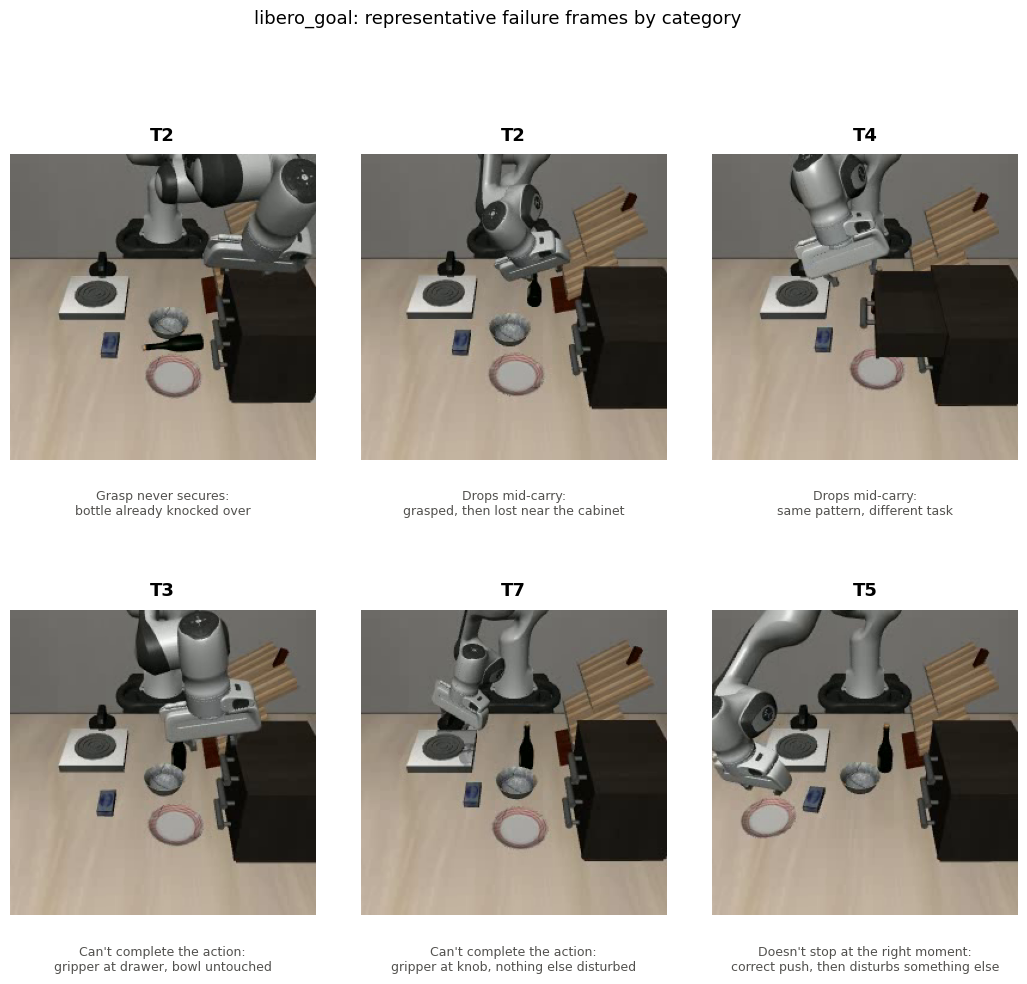

In [11]:
# !pip install -q opencv-python-headless  # already a project dependency, see requirements.txt
import cv2
import matplotlib.pyplot as plt

def get_frame(video_path, fraction):
    """Grab one frame at a fractional position (0=first, 1=last) through the video."""
    cap = cv2.VideoCapture(video_path)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idx = min(int(n_frames * fraction), n_frames - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ok else None

VIDEO_DIR = f"{DATA_DIR}/videos/failures"

# One representative example per failure category, confirmed by watching all 9 saved
# failure videos frame-by-frame (see the Findings summary for the full breakdown).
examples = [
    ("T2", "libero_goal_2_ep0_fail.mp4", 0.35,
     "Grasp never secures:\nbottle already knocked over"),
    ("T2", "libero_goal_2_ep12_fail.mp4", 0.99,
     "Drops mid-carry:\ngrasped, then lost near the cabinet"),
    ("T4", "libero_goal_4_ep30_fail.mp4", 0.99,
     "Drops mid-carry:\nsame pattern, different task"),
    ("T3", "libero_goal_3_ep20_fail.mp4", 0.99,
     "Can't complete the action:\ngripper at drawer, bowl untouched"),
    ("T7", "libero_goal_7_ep49_fail.mp4", 0.99,
     "Can't complete the action:\ngripper at knob, nothing else disturbed"),
    ("T5", "libero_goal_5_ep17_fail.mp4", 0.99,
     "Doesn't stop at the right moment:\ncorrect push, then disturbs something else"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 10))
for ax, (task, fname, frac, caption) in zip(axes.flat, examples):
    frame = get_frame(f"{VIDEO_DIR}/{fname}", frac)
    ax.imshow(frame)
    ax.set_title(task, fontsize=13, fontweight="bold", pad=10)
    ax.axis("off")
    ax.text(0.5, -0.1, caption, transform=ax.transAxes, ha="center", va="top",
            fontsize=9, color="#52514e")
fig.suptitle("libero_goal: representative failure frames by category", fontsize=13, y=1.02)
fig.subplots_adjust(hspace=0.45, wspace=0.15)
plt.show()

**Per-task breakdown, from watching every saved failure video:**

- **`T2`** ("put the wine bottle on top of the drawer", 5/50 fail) — grasp on the bottle isn't reliable. In 2 of 3 saved failures, the reach/grasp attempt never actually secures the bottle, it tips over before being properly held. In the 3rd, the bottle is grasped successfully and carried partway toward the cabinet, then dropped before the placement finishes. Either way it ends up lying on its side near the bowl instead of upright on the cabinet.
- **`T3`** ("open the top drawer and put the bowl inside", 3/50 fail) — all 3 saved failures look nearly identical start to finish: the gripper reaches the drawer, but the pull-to-open motion doesn't succeed. Since opening the drawer is required before the bowl can go inside, the task stalls completely at this first step, the bowl is never even touched.
- **`T4`** ("put the bowl on top of the drawer", 1/50 fail) — picks up the bowl successfully, then drops it partway through carrying it, the same "drops mid-carry" pattern as T2's third case. Afterward it opens a nearby drawer, unrelated to this task, instead of recovering.
- **`T5`** ("push the plate to the front of the stove", 1/50 fail) — performs the correct action (pushes the plate forward), but doesn't stop there, it continues on and touches another object afterward, likely disturbing the plate's final position.
- **`T7`** ("turn on the stove", 1/50 fail) — gripper reaches the stove's knob correctly; unlike the others, nothing else in the scene is disturbed. Same category as T3: reaches the right spot, but the manipulation action itself (press/turn, instead of pull) doesn't succeed.

**Failure taxonomy:**

| Failure type | Tasks affected | What it looks like |
|---|---|---|
| Grasp never secures | T2 (2 of 3 failures) | Fumbles the pickup entirely, object tips over before being held |
| Drops object mid-carry | T2 (1 of 3), T4 | Picks it up successfully, loses grip before finishing the placement |
| Can't complete the manipulation action | T3, T7 | Reaches the right spot (drawer/knob), but the pull/press motion itself fails |
| Doesn't stop at the right moment | T5 | Performs the correct action, then keeps going and disturbs something else |

None of these four failure types line up with scene clutter or starting distance (Section 5), they're all about physical manipulation precision, grasping, holding, pulling, and knowing when to stop, not about how messy or far away the scene is.

## 8. Object type & task complexity (exploratory)

Distractor density and gripper distance (Section 5) didn't predict failure, but the video review just above did turn up two real patterns: bottle-handling tasks and compound (two-step) instructions are the weak spots. This section tests those two pattern.

With only 10 tasks (and only 2 involving a bottle, only 1 compound), treat this as a quick check, not a real statistical test, the sample is far too small for the numbers below to be trustworthy on their own.

In [13]:
# Both flags derived purely from the instruction text already saved, no new data needed.
nlp["is_bottle"] = nlp["instruction"].str.contains("bottle", case=False)
nlp["is_compound"] = nlp["instruction"].str.contains(" and ", case=False)

bottle_summary = nlp.groupby("is_bottle").agg(
    n_tasks=("task_short", "count"),
    avg_success=("success_pct", "mean"),
    tasks=("task_short", lambda s: ", ".join(s)),
)
compound_summary = nlp.groupby("is_compound").agg(
    n_tasks=("task_short", "count"),
    avg_success=("success_pct", "mean"),
    tasks=("task_short", lambda s: ", ".join(s)),
)

# Reformat as display-friendly tables (True/False -> Yes/No, readable column names)
# instead of raw print(), which loses the grouped-index formatting in most renderers.
bottle_table = bottle_summary.reset_index().rename(columns={
    "is_bottle": "Bottle-handling?", "n_tasks": "Tasks (n)",
    "avg_success": "Avg. success (%)", "tasks": "Task IDs",
})
bottle_table["Bottle-handling?"] = bottle_table["Bottle-handling?"].map({True: "Yes", False: "No"})
bottle_table["Avg. success (%)"] = bottle_table["Avg. success (%)"].round(1)

compound_table = compound_summary.reset_index().rename(columns={
    "is_compound": "Compound instruction?", "n_tasks": "Tasks (n)",
    "avg_success": "Avg. success (%)", "tasks": "Task IDs",
})
compound_table["Compound instruction?"] = compound_table["Compound instruction?"].map({True: "Yes", False: "No"})
compound_table["Avg. success (%)"] = compound_table["Avg. success (%)"].round(1)

print("Bottle-handling tasks vs. everything else:")
display(bottle_table)
print("\nCompound (two-step) tasks vs. single-step tasks:")
display(compound_table)

fig = make_subplots(rows=1, cols=2, subplot_titles=("Bottle-handling?", "Compound instruction?"))
fig.add_bar(x=["No", "Yes"], y=[bottle_summary.loc[False, "avg_success"], bottle_summary.loc[True, "avg_success"]],
            marker_color=["#2a78d6", "#fab219"], text=[f"n={bottle_summary.loc[False,'n_tasks']}", f"n={bottle_summary.loc[True,'n_tasks']}"],
            textposition="outside", row=1, col=1)
fig.add_bar(x=["No", "Yes"], y=[compound_summary.loc[False, "avg_success"], compound_summary.loc[True, "avg_success"]],
            marker_color=["#2a78d6", "#fab219"], text=[f"n={compound_summary.loc[False,'n_tasks']}", f"n={compound_summary.loc[True,'n_tasks']}"],
            textposition="outside", row=1, col=2)
fig.update_yaxes(title_text="Avg. success rate (%)", range=[0, 112], row=1, col=1)
fig.update_yaxes(range=[0, 112], row=1, col=2)
fig.update_layout(template="plotly_white", height=430, width=900, showlegend=False,
                   margin=dict(l=10, r=10, t=60, b=40),
                   title="libero_goal: does object type or instruction structure line up with success?")
fig.show()

Bottle-handling tasks vs. everything else:


,Bottle-handling?,Tasks (n),Avg. success (%),Task IDs
0,No,8,98.5,"T0, T1, T3, T4, T5, T6, T7, T8"
1,Yes,2,95.0,"T2, T9"



Compound (two-step) tasks vs. single-step tasks:


,Compound instruction?,Tasks (n),Avg. success (%),Task IDs
0,No,9,98.2,"T0, T1, T2, T4, T5, T6, T7, T8, T9"
1,Yes,1,94.0,T3


**Takeaway, with an important nuance:** bottle-handling tasks average 95% vs. 98.5% for everything else, but that gap is driven entirely by `T2` (90%), the *other* bottle task, `T9` ("put the wine bottle on the rack"), is a perfect 100%. So this isn't "MolmoAct2 struggles with bottles in general," it's specifically the "place it precisely on top of the cabinet" placement in `T2` that's hard, not the bottle itself. Similarly, the compound-instruction comparison is really just `T3` (n=1) vs. everyone else, not a real group average, we only have one compound task in this suite to look at. Both results point in the direction the video review suggested, but neither is strong evidence on its own at this sample size, exactly why we called this section exploratory.

## Findings summary

- **Overall success rate: 97.8%** (489/500 episodes) — near-ceiling performance on this suite. 5 of 10 tasks are perfect (100%).
- **Two tasks stand out statistically:** `T2` ("put the wine bottle on top of the drawer", 90%) has a confidence interval clearly separated from the perfect tasks, a real weak spot. `T3` ("open the top drawer and put the bowl inside", 94%) is weaker on paper but its interval overlaps enough with the perfect tasks that part of the gap could be sampling noise at n=50.
- **Failures come from physical manipulation precision, not scene difficulty.** ("Manipulation precision" just means how accurately the robot arm executes an action, grasping firmly, holding on while moving, pulling something open, stopping at the right moment, as opposed to *deciding* the wrong thing to do.) Watching every one of the 9 saved failure videos frame-by-frame turned up four distinct failure types, not one:
  - **Grasp never secures** (`T2`, 2 of 3 saved failures) — the pickup attempt fumbles and the object tips over before being properly held.
  - **Drops object mid-carry** (`T2`'s 3rd failure, `T4`) — grasped successfully, then lost before the placement finishes.
  - **Can't complete the manipulation action** (`T3`, `T7`) — reaches the right spot (drawer/knob) but the pull/press motion itself doesn't succeed; `T3` stalls so completely on this that the bowl is never even touched in any of its 3 failures.
  - **Doesn't stop at the right moment** (`T5`) — performs the correct action, then keeps going and disturbs something else afterward.
- **Model weaknesses implied by the above** (not just task failures):
  - **Placement-specific, not object-shape-specific, grasp/hold instability**: `T2` and `T9` both involve the *same* object (a wine bottle), yet `T2` (placing it on top of the drawer/cabinet) is the suite's weakest task at 90%, while `T9` (placing it on a rack) is a perfect 100%. So it isn't "bottles are hard, bowls are easy", the object is identical across both, what differs is the specific placement target. The harder-to-support claim would be "tall/narrow objects are harder"; the better-supported one is "this specific placement (on top of a tall cabinet) is harder to execute reliably," see Section 8 for the full check. This is reinforced from the other direction by `T4` ("put the bowl on top of the drawer", 98%): a completely different object (bowl, not bottle) aimed at the *same* placement target, and it's imperfect too. `T2` and `T4` are the only two tasks in the suite that require placing something on top of the drawer/cabinet, and both fail, that's a cleaner signal than the bottle comparison alone, since it holds the placement fixed and varies the object, instead of the other way around.
  - **Compound-instruction execution, not raw drawer-pulling skill**: `T0` ("open the *middle* drawer," a single-step task) succeeds 100%, which rules out "can't pull a drawer" as the explanation for `T3`'s failures; the more likely weakness is reliably executing the *first* step of a two-step instruction. (Section 8 also flags this is just a 1-task-vs-9-tasks comparison, not a real group average.)
  - **Weak stopping/completion detection** (`T5`): continues acting after the goal state is already reached.
- **Every failure timed out** rather than stopping early — all 9 saved failure videos run the full 300 frames. MolmoAct2 doesn't misfire and quit; it keeps trying (or stalling) until the clock runs out.
- **No significant scene-property correlations within this suite** (distractor density, gripper distance): both `|r|` well under 0.3 and `p` well over 0.05, and this now has a mechanistic explanation, the failures we found are about grasp/hold/pull precision, not about how cluttered or far away the scene is, so it's unsurprising those two scene properties don't predict them. With only 10 tasks this is also a low-power test either way; the properly-powered version needs all 4 suites pooled together.
- **This suite alone cannot answer the "how does success vary across suites" half of the research question** — that requires Spatial, Object, and Long results merged in alongside this one. Once available, worth checking whether the same specific placement (on top of a tall object) or the same action types (e.g., drawer-pulling) show similarly low reliability in the Object and Spatial suites, that would point to a general MolmoAct2 weakness rather than something specific to the Goal suite's phrasing.

## Recommendations & mitigations

Given the scope of this project, we can't retrain MolmoAct2 ourselves. Here are some of the recommendations based on the findings above:

Each of these problems has one thing in common: **the general skill already works, just not in this specific case.** That's exactly the situation fine-tuning is meant for, targeted, additional training on a narrow gap, not training from scratch. So the recommendations below use fine-tuning specifically, alongside a lighter-weight patch that needs no training at all.

**Problem 1: it fumbles or drops the wine bottle when placing it on the cabinet (`T2`)**
- **Fine-tune on more examples:** it grasps and carries the *same* wine bottle perfectly in `T9` ("put the wine bottle on the rack," 100%), so this isn't a general grasping or object-shape problem. `T2` and `T4` (below) are the *only two* tasks in this suite that require placing an object on top of the drawer/cabinet, and both have failures, so the gap looks specific to that placement, not to the bottle. A targeted fine-tune on more examples of placing objects on top of tall/elevated surfaces should close this gap without touching anything else that already works.
- **Quick patch, no fine-tuning needed:** after every grasp/placement, add a simple check, "is the object actually resting stably where it was placed?" If not, stop and retry instead of continuing.

**Problem 2: it also drops the bowl when placing it on top of the cabinet (`T4`)**
- **Fine-tune on more examples:** same underlying gap as `T2`, since it's the *same target placement* ("on top of the drawer"), just a different object (bowl instead of bottle). This strengthens Problem 1's fine-tuning recommendation, more training examples of this specific placement should help both tasks at once, not just one.
- **Quick patch, no fine-tuning needed:** the same stability check as Problem 1, since it's the same failure mode (drops mid-carry).

**Problem 3: it gets stuck on the first half of a two-step task (`T3`)**
- **Fine-tune on more two-step examples:** it can already open a drawer perfectly on its own (`T0` is 100%), so the drawer-pulling skill isn't the gap, executing it as *step one of two* is. A targeted fine-tune on more compound (multi-step) instructions should help it carry that same skill into longer sequences.
- **Quick patch, no fine-tuning needed:** split the instruction into two separate steps for it, tell it "open the drawer" first, wait until that's done, then tell it "put the bowl inside." Don't hand it both at once.

**Problem 4: it can't complete a simple press/turn action (`T7`)**
- **Fine-tune on more examples:** unlike `T3`, this is a **single-step** task, "turn on the stove" has no second step, so this isn't a sequencing problem. It looks like a different action type (pressing/turning a knob) is less reliable than pulling (which works fine in `T0`/`T3`). Caveat: this suite has no other single-step press/turn task to compare against, so we can't yet confirm whether this is a general weakness with that action type or specific to this one task, worth checking once Object/Spatial suite data is available.
- **Quick patch, no fine-tuning needed:** the same "did the action actually register" check as Problems 1 and 2, applied to button/knob presses instead of placements.

**Problem 5: it doesn't know when to stop (`T5`)**
- **Fine-tune with clearer stop signals:** it already performs the correct action, so the gap is recognizing "the goal is done now, stop moving," not the action itself. Fine-tuning on data with a clearer completion signal should help it learn when to stop.
- **Quick patch, no fine-tuning needed:** watch for the moment the goal is actually reached, and cut the robot off there instead of letting it keep going.

**The simple version:** none of these are things we can fix by editing our evaluation script, they're either a targeted fine-tune of the model, or an extra safety check added around it when it's used. That's exactly why this kind of failure analysis matters: it turns "the model failed sometimes" into a specific, actionable list of what to fix and how.